# 🎯 Proyecto 1: Regresión Lineal Simple

## Dataset: Salary Dataset — Predicción de Salario por Años de Experiencia

---

## 🔍 Objetivo

Construir un modelo de **Regresión Lineal Simple** que prediga el salario de un empleado a partir de sus años de experiencia.

Al completar este notebook serás capaz de:

- Preprocesar datos para Machine Learning.
- Entrenar y evaluar un modelo de regresión lineal simple.
- Interpretar los coeficientes β₀ y β₁.
- Analizar residuos y métricas de evaluación.

## ✨ ¿Qué es la Regresión Lineal Simple?

Modela la relación entre **una variable de entrada (X) y una salida (y)** con una línea recta:

```
ŷ = β₀ + β₁ · X
```

- β₀ → Intercepto (valor de y cuando X = 0)
- β₁ → Pendiente (cuánto aumenta y por cada unidad de X)
- X → Años de experiencia
- ŷ → Salario estimado

    **Intuición:** Es la línea que "mejor se ajusta" a la nube de puntos del scatter plot.

---

## ⚙️ Paso 0 — Importar Librerías

Ejecuta la siguiente celda para importar todo lo necesario.

In [49]:
# Importa: pandas, numpy, matplotlib.pyplot, seaborn
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np
import os
import pandas as pd
import seaborn as sns
import sys

# Desde sklearn.model_selection importa train_test_split
from sklearn.model_selection import train_test_split, cross_val_score

# Desde sklearn.linear_model importa LinearRegression
from sklearn.linear_model import LinearRegression

# Desde sklearn.metrics importa mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Configura el estilo de matplotlib con: plt.style.use('seaborn-v0_8-whitegrid')
plt.style.use("seaborn-v0_8-whitegrid")

# Imprime un mensaje de confirmación
print("✅ Las librerías se han cargado y configurado correctamente.")

✅ Las librerías se han cargado y configurado correctamente.


---

## 📂 Paso 1 — Cargar y Explorar los Datos

Descarga el dataset desde Kaggle: https://www.kaggle.com/datasets/abhishek14398/salary-dataset-simple-linear-regression

El archivo se llama Salary_dataset.csv.

In [50]:
# Carga el CSV con pd.read_csv() y muestra las primeras 5 filas con .head()
ruta_csv = os.path.join("dataset/Salary_dataset.csv")
df = pd.read_csv(ruta_csv)

print("📌 PRIMERAS 5 FILAS\n")
display(df.head())

print("\n" + "=" * 50 + "\n")

# Imprime: número de filas, número de columnas con df.shape
print("📄 DIMENSIONES DEL DATAFRAME\n")
filas, columnas = df.shape
print(f"Número de filas: {filas}")
print(f"Número de columnas: {columnas}")

print("\n" + "=" * 50 + "\n")

# Tipos de datos (df.info())
print("👀 TIPOS DE DATOS\n")
df.info()

print("\n" + "=" * 50 + "\n")

# Valores nulos (df.isnull().sum())
print("🗑️VALORES NULOS POR COLUMNA\n")
print(df.isnull().sum())

print("\n" + "=" * 50 + "\n")

# Muestra las estadísticas descriptivas con .describe().round(2)
print("📉 ESTADÍSTICAS DESCRIPTIVAS\n")
display(df.describe().round(2))

📌 PRIMERAS 5 FILAS



,Unnamed: 0,YearsExperience,Salary
0,0,1.2,39344.0
1,1,1.4,46206.0
2,2,1.6,37732.0
3,3,2.1,43526.0
4,4,2.3,39892.0




📄 DIMENSIONES DEL DATAFRAME

Número de filas: 30
Número de columnas: 3


👀 TIPOS DE DATOS

<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Unnamed: 0       30 non-null     int64  
 1   YearsExperience  30 non-null     float64
 2   Salary           30 non-null     float64
dtypes: float64(2), int64(1)
memory usage: 852.0 bytes


🗑️VALORES NULOS POR COLUMNA

Unnamed: 0         0
YearsExperience    0
Salary             0
dtype: int64


📉 ESTADÍSTICAS DESCRIPTIVAS



,Unnamed: 0,YearsExperience,Salary
count,30.00,30.00,30.00
mean,14.50,5.41,76004.00
std,8.80,2.84,27414.43
min,0.00,1.20,37732.00
25%,7.25,3.30,56721.75
50%,14.50,4.80,65238.00
75%,21.75,7.80,100545.75
max,29.00,10.60,122392.00


---

## 📊 Paso 2 — Análisis Exploratorio (EDA)

Antes de entrenar el modelo debemos entender visualmente los datos

🚨 CANTIDAD DE VALORES NULOS

YearsExperience    0
Salary             0
dtype: int64




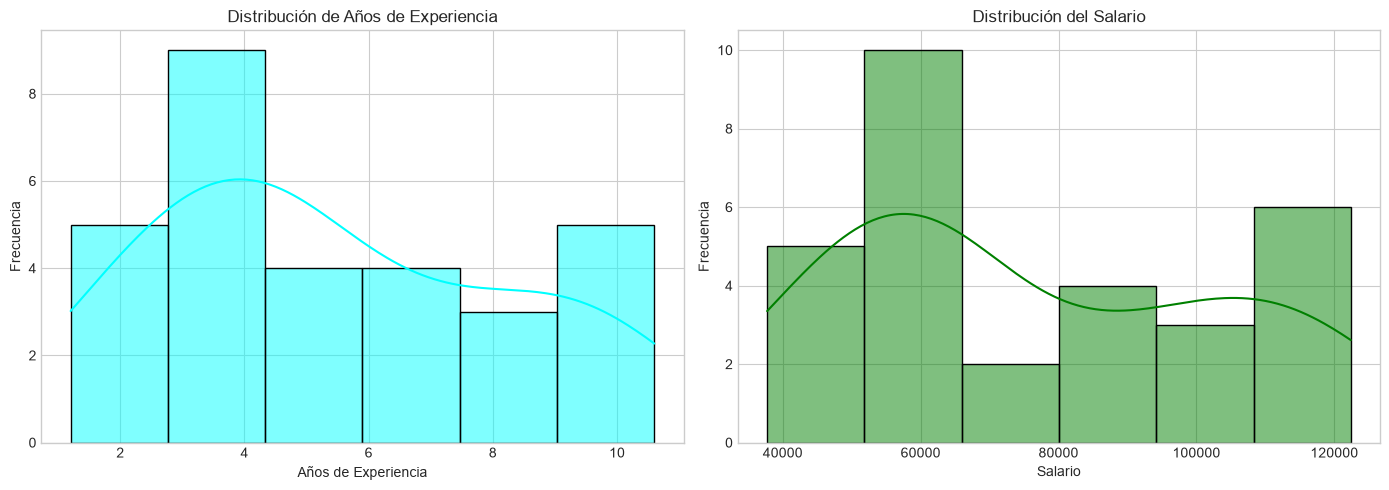

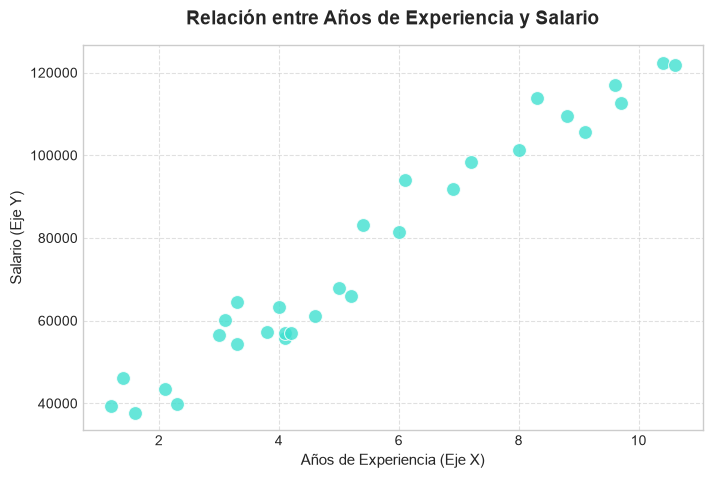



🔗 RESULTADO DE LA CORRELACIÓN

Coeficiente de correlación de Pearson: 0.9782


📝 INTERPRETACIÓN:

Dado que la correlación es de 0.9782 (> 0.95), existe una relación lineal positiva extremadamente fuerte. La correlación es EXCELENTE para entrenar un modelo de regresión lineal simple, ya que el aumento en los años de experiencia predice de forma casi perfecta el aumento del salario.


In [51]:
# Verificamos que no haya valores nulos
print("🚨 CANTIDAD DE VALORES NULOS\n")
print(df[["YearsExperience", "Salary"]].isnull().sum())

print("\n" + "=" * 50 + "\n")

# Crea un subplot con 2 histogramas: uno para YearsExperience y otro para Salary
    #Subplot con 2 histogramas
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 5))

    # Histograma para YearsExperience
sns.histplot(
    data=df, x="YearsExperience", kde=True, color="aqua", ax=axes[0]
)
axes[0].set_title("Distribución de Años de Experiencia")
axes[0].set_xlabel("Años de Experiencia")
axes[0].set_ylabel("Frecuencia")

    # Histograma para Salary
sns.histplot(data=df, x="Salary", kde=True, color="green", ax=axes[1])
axes[1].set_title("Distribución del Salario")
axes[1].set_xlabel("Salario")
axes[1].set_ylabel("Frecuencia")

     # Ajusta los espacios automáticamente
plt.tight_layout() 
plt.show()

print("\n" + "=" * 50 + "\n")

# Crea un scatter plot de YearsExperience (eje X) vs Salary (eje Y). Añade título, etiquetas de ejes y estilo.
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df, x="YearsExperience", y="Salary", color="turquoise", s=100, alpha=0.8
)

    # Configuración del estilo y etiquetas para los gráficos
plt.title(
    "Relación entre Años de Experiencia y Salario",
    fontsize=14,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Años de Experiencia (Eje X)", fontsize=11)
plt.ylabel("Salario (Eje Y)", fontsize=11)
plt.grid(True, linestyle="--", alpha=0.6)

plt.show()

print("\n" + "=" * 50 + "\n")

# Calcula la correlación de Pearson entre YearsExperience y Salary con .corr()
correlacion_matrix = df[["YearsExperience", "Salary"]].corr(method="pearson")
valor_correlacion = correlacion_matrix.loc["YearsExperience", "Salary"]

# Imprime el resultado e interpreta: correlación > 0.95 es excelente para regresión linea
print("🔗 RESULTADO DE LA CORRELACIÓN\n")
print(f"Coeficiente de correlación de Pearson: {valor_correlacion:.4f}")

print("\n")

print("📝 INTERPRETACIÓN:\n")
if valor_correlacion > 0.95:
    print(
        f"Dado que la correlación es de {valor_correlacion:.4f} (> 0.95), "
        "existe una relación lineal positiva extremadamente fuerte. "
        "La correlación es EXCELENTE para entrenar un modelo de regresión lineal simple, "
        "ya que el aumento en los años de experiencia predice de forma casi perfecta el aumento del salario."
    )
else:
    print(
        f"La correlación es de {valor_correlacion:.4f}. Aunque existe relación, "
        "no supera el umbral del 0.95 sugerido para un ajuste lineal casi perfecto."
    )

---

## 📐 Paso 3 — Preparación de los Datos

Separamos las variables y dividimos en entrenamiento (80%) y prueba (20%).

In [52]:
# Crea X = df[['YearsExperience']]  (doble corchete para que sea 2D)
X = df[["YearsExperience"]]

# Crea y = df['Salary']
y = df["Salary"]

# Imprime las formas (shape) de X e y
print("🎨 FORMA (SHAPE) DE LAS MATRICES\n")
print(f"Forma de X (Características): {X.shape}")
print(f"Forma de y (Variable Objetivo): {y.shape}")

print("\n" + "=" * 50 + "\n")

# Usa train_test_split con test_size=0.2 y random_state=42
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Imprime cuántas muestras hay en entrenamiento y prueba
print("📊 DISTRIBUCIÓN DE MUESTRAS\n")
print(f"Muestras en Entrenamiento (X_train): {X_train.shape[0]}")
print(f"Muestras en Prueba (X_test): {X_test.shape[0]}")
print(f"Total de muestras en el dataset: {df.shape[0]}")

🎨 FORMA (SHAPE) DE LAS MATRICES

Forma de X (Características): (30, 1)
Forma de y (Variable Objetivo): (30,)


📊 DISTRIBUCIÓN DE MUESTRAS

Muestras en Entrenamiento (X_train): 24
Muestras en Prueba (X_test): 6
Total de muestras en el dataset: 30


---

## 🤖 Paso 4 — Entrenar el Modelo

El método .fit() calcula los coeficientes óptimos β₀ y β₁.

🧠 PARÁMETROS DEL MODELO APRENDIDOS

Intercepto (β₀ - Salario base estimado): 24380.20
Coeficiente (β₁ - Incremento por año de exp.): 9423.82

La ecuación de la recta es: Salario = 24380.20 + (9423.82 * YearsExperience)




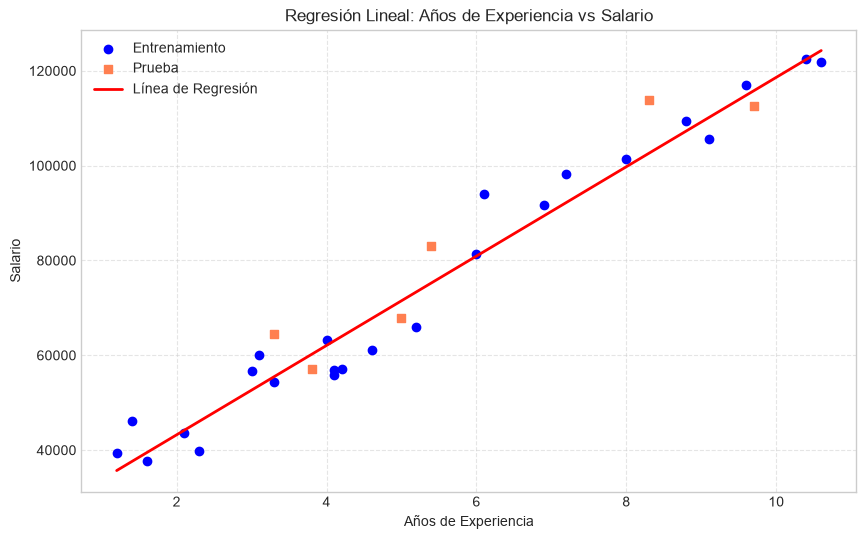

In [53]:
# Crear e instanciar el modelo / Crea una instancia de LinearRegression()
modelo = LinearRegression()

# Llama a .fit(X_train, y_train)
modelo.fit(X_train, y_train)

# Imprime modelo.intercept_ (β₀) y modelo.coef_[0] (β₁) con formato claro
print("🧠 PARÁMETROS DEL MODELO APRENDIDOS\n")
print(f"Intercepto (β₀ - Salario base estimado): {modelo.intercept_[0]:.2f}" if hasattr(modelo.intercept_, '__len__') else f"Intercepto (β₀ - Salario base estimado): {modelo.intercept_:.2f}")
print(f"Coeficiente (β₁ - Incremento por año de exp.): {modelo.coef_[0]:.2f}")
print(f"\nLa ecuación de la recta es: Salario = {modelo.intercept_:.2f} + ({modelo.coef_[0]:.2f} * YearsExperience)")

print("\n" + "="*50 + "\n")

# Traza el scatter plot de los datos de entrenamiento (azul) y prueba (coral)
plt.figure(figsize=(10, 6))

plt.scatter(X_train['YearsExperience'], y_train, color='blue', label='Entrenamiento')
plt.scatter(X_test['YearsExperience'], y_test, color='coral', marker='s', label='Prueba')

# Superpone la línea de regresión generando X_linea con np.linspace
X_min = df['YearsExperience'].min()
X_max = df['YearsExperience'].max()
X_linea = np.linspace(X_min, X_max, 100).reshape(-1, 1)
X_linea = pd.DataFrame(X_linea, columns=["YearsExperience"])

# Usa modelo.predict(X_linea) para obtener los valores de la línea
y_linea = modelo.predict(X_linea)

    # Dibujar la línea sobre el gráfico anterior
plt.plot(X_linea, y_linea, color='red', linewidth=2, label='Línea de Regresión')

    # Añadir títulos y leyenda para completar el gráfico
plt.title("Regresión Lineal: Años de Experiencia vs Salario")
plt.xlabel("Años de Experiencia")
plt.ylabel("Salario")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

---

## ⚡ Paso 5 — Evaluación del Modelo

Calculamos las métricas sobre los datos de **prueba** (datos que el modelo no vio durante el entrenamiento).

| Métrica | Fórmula | Valor ideal |
| :--- | :--- | :--- |
| **MAE** | $\text{mean}(\|y - \hat{y}\|)$ | Lo más bajo posible |
| **MSE** | $\text{mean}((y - \hat{y})^2)$ | Lo más bajo posible |
| **RMSE** | $\sqrt{\text{MSE}}$ | Lo más bajo posible |
| **R²** | $1 - \text{SS\_res}/\text{SS\_tot}$ | Cercano a 1.0 |

> **Valores esperados para este dataset:** $R^2 \ge 0.90$, $\text{MAE} < \$5,000$

In [54]:
# Genera predicciones: y_pred = modelo.predict(X_test)
y_pred = modelo.predict(X_test)

# Crea un DataFrame comparando: Años_Exp, Salario_Real, Salario_Predicho, Error
df_comparacion = pd.DataFrame({
    'Años_Exp': X_test['YearsExperience'].values,
    'Salario_Real': y_test.values,
    'Salario_Predicho': y_pred,
    'Error': y_test.values - y_pred
})

# Imprime la tabla
print("📊 TABLA DE COMPARACIÓN (DATOS DE PRUEBA)\n")
print(df_comparacion.to_string(index=False))

print("\n" + "="*60 + "\n")

# Calcula e imprime MAE, MSE, RMSE y R² usando las funciones de sklearn.metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

# Muestra los resultados de forma clara con etiquetas
print("📊 MÉTRICAS DE RENDIMIENTO DEL MODELO\n")
print(f"Error Absoluto Medio (MAE): ${mae:,.2f}")
print(f"Error Cuadrático Medio (MSE): ${mse:,.2f}")
print(f"Raíz del Error Cuadrático Medio (RMSE): ${rmse:,.2f}")
print(f"Coeficiente de Determinación (R²): {r2:.4f}")

📊 TABLA DE COMPARACIÓN (DATOS DE PRUEBA)

 Años_Exp  Salario_Real  Salario_Predicho        Error
      9.7      112636.0     115791.210113 -3155.210113
      5.0       67939.0      71499.278095 -3560.278095
      8.3      113813.0     102597.868661 11215.131339
      5.4       83089.0      75268.804224  7820.195776
      3.3       64446.0      55478.792045  8967.207955
      3.8       57190.0      60190.699707 -3000.699707


📊 MÉTRICAS DE RENDIMIENTO DEL MODELO

Error Absoluto Medio (MAE): $6,286.45
Error Cuadrático Medio (MSE): $49,830,096.86
Raíz del Error Cuadrático Medio (RMSE): $7,059.04
Coeficiente de Determinación (R²): 0.9024


---

## 👀 Paso 6 — Análisis de Residuos

Los **residuos** son $e = y - \hat{y}$. Analizarlos nos dice si el modelo es adecuado.

> **Buen modelo:** residuos distribuidos aleatoriamente alrededor de 0, sin patrón visible.  
>
> **Problema:** si hay curva o patrón → relación no es lineal → usar regresión polinómica.

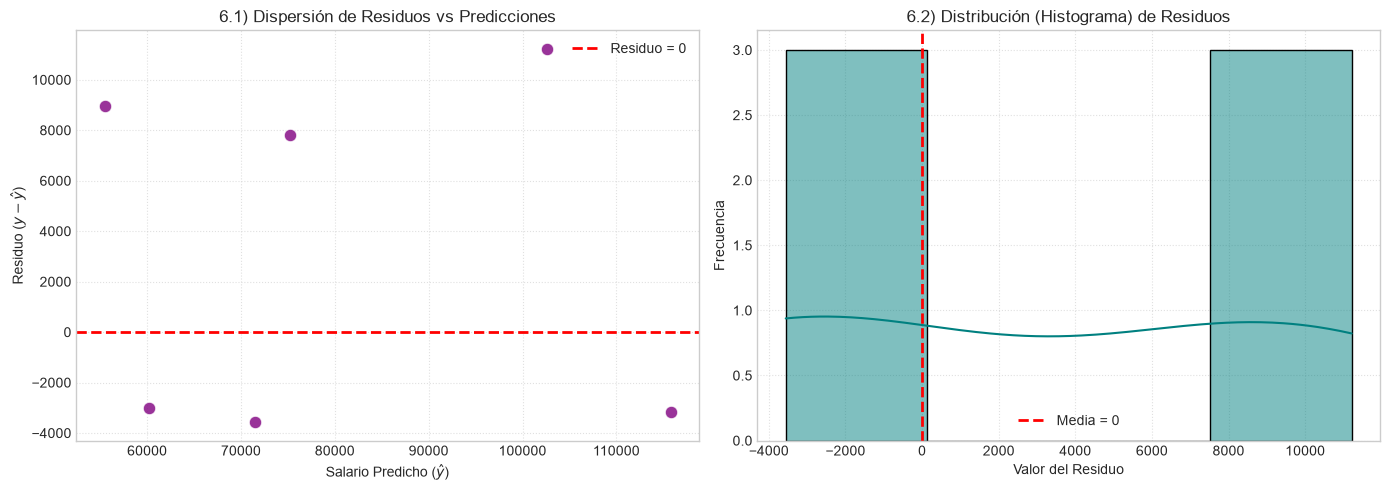

In [55]:
# Calcula residuos = y_test.values - y_pred
residuos = y_test.values - y_pred

# Crea 2 subplots lado a lado: (6.1 y 6.2)
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 5))

#   1) Scatter: residuos vs y_pred (con línea horizontal en y=0)
sns.scatterplot(x=y_pred, y=residuos, color='purple', s=80, alpha=0.8, ax=axes[0])
axes[0].axhline(y=0, color='red', linestyle='--', linewidth=2, label='Residuo = 0')

    # Personalización del primer gráfico (6.1)
axes[0].set_title('6.1) Dispersión de Residuos vs Predicciones')
axes[0].set_xlabel(r'Salario Predicho ($\hat{y}$)')
axes[0].set_ylabel(r'Residuo ($y - \hat{y}$)')
axes[0].legend()
axes[0].grid(True, linestyle=':', alpha=0.6)

#   2) Histograma de residuos (con línea vertical en x=0)
sns.histplot(residuos, kde=True, color='teal', ax=axes[1])
axes[1].axvline(x=0, color='red', linestyle='--', linewidth=2, label='Media = 0')

    # Personalización del segundo gráfico (6.2)
axes[1].set_title('6.2) Distribución (Histograma) de Residuos')
axes[1].set_xlabel('Valor del Residuo')
axes[1].set_ylabel('Frecuencia')
axes[1].legend()
axes[1].grid(True, linestyle=':', alpha=0.6)

# Ajustar diseño y mostrar
plt.tight_layout()
plt.show()

---

## ⚠️ Paso 7 — ¿Qué hacer si el modelo no predice bien?

Si R² < 0.80, aplica estas estrategias de diagnóstico y ajuste.

In [56]:
# Detecta outliers: calcula umbral = 2 * residuos.std()
umbral = 2 * residuos.std()

# Encuentra índices donde np.abs(residuos) > umbral
indices_outliers = np.where(np.abs(residuos) > umbral)[0]

# Imprime las predicciones con error grande
print("🚨 DETECCIÓN DE OUTLIERS (ERRORES GRANDES)\n")
if len(indices_outliers) > 0:
    # Usamos el DataFrame de comparación que creamos en el paso anterior
    print(df_comparacion.iloc[indices_outliers].to_string(index=False))
else:
    print(f"No se detectaron outliers. Todos los residuos están dentro del umbral de tolerancia ({umbral:.2f}).")

print("\n" + "="*70 + "\n")

# Calcula R² tanto en entrenamiento como en prueba
r2_train = modelo.score(X_train, y_train)
r2_test = r2_score(y_test, y_pred)

# Imprime ambos y la diferencia
diferencia_r2 = r2_train - r2_test

print("🔍 DIAGNÓSTICO DE OVERFITTING / UNDERFITTING\n")
print(f"R² en Entrenamiento: {r2_train:.4f}")
print(f"R² en Prueba:        {r2_test:.4f}")
print(f"Diferencia (Train - Test): {diferencia_r2:.4f}")

# Si diferencia > 0.10 → posible overfittingç
if diferencia_r2 > 0.10:
    print("⚠️ Diagnóstico: Posible OVERFITTING. El modelo rinde bien con datos conocidos pero pierde precisión con datos nuevos.")
else:
    print("✅ Diagnóstico: Modelo GENERALIZADO. La diferencia es baja, lo que indica que el modelo es estable con datos nuevos.")

print("\n" + "="*70 + "\n")

# Usa cross_val_score de sklearn.model_selection con cv=5 y scoring='r2'
X_df = pd.DataFrame(X, columns=['YearsExperience'])
scores_r2 = cross_val_score(modelo, X_df, y, cv=5, scoring='r2')

# Imprime los R² por fold, el promedio y la desviación estándar
print("🔄 VALIDACIÓN CRUZADA (K-FOLD CV = 5)\n")
for i, score in enumerate(scores_r2, 1):
    print(f"Fold {i}: R² = {score:.4f}")
print(f"\nR² Promedio:            {scores_r2.mean():.4f}")
print(f"Desviación Estándar (σ): {scores_r2.std():.4f}")

print("\n" + "="*70 + "\n")

🚨 DETECCIÓN DE OUTLIERS (ERRORES GRANDES)

No se detectaron outliers. Todos los residuos están dentro del umbral de tolerancia (12734.44).


🔍 DIAGNÓSTICO DE OVERFITTING / UNDERFITTING

R² en Entrenamiento: 0.9645
R² en Prueba:        0.9024
Diferencia (Train - Test): 0.0621
✅ Diagnóstico: Modelo GENERALIZADO. La diferencia es baja, lo que indica que el modelo es estable con datos nuevos.


🔄 VALIDACIÓN CRUZADA (K-FOLD CV = 5)

Fold 1: R² = 0.3596
Fold 2: R² = -1.2442
Fold 3: R² = 0.2505
Fold 4: R² = 0.2970
Fold 5: R² = 0.0703

R² Promedio:            -0.0534
Desviación Estándar (σ): 0.6032




---

## 🚀 Paso 8 — Hacer Predicciones Nuevas

In [59]:
# Crea un DataFrame con nuevos valores de YearsExperience: [1.5, 5.0, 8.0, 10.0, 12.0]
nuevos_valores = [1.5, 5.0, 8.0, 10.0, 12.0]
df_nuevos = pd.DataFrame(nuevos_valores, columns=['YearsExperience'])

# Usa modelo.predict() para obtener sus salarios estimados
nuevas_predicciones = modelo.predict(df_nuevos)

# Imprime cada predicción de forma legible
print("✨ PREDICCIONES NUEVAS\n")
for exp, sueldo_est in zip(nuevos_valores, nuevas_predicciones):
    print(f"Para {exp:4.1f} años de experiencia → Salario Estimado: ${sueldo_est:,.2f}")
    
print("\n" + "="*70 + "\n")

✨ PREDICCIONES NUEVAS

Para  1.5 años de experiencia → Salario Estimado: $38,515.92
Para  5.0 años de experiencia → Salario Estimado: $71,499.28
Para  8.0 años de experiencia → Salario Estimado: $99,770.72
Para 10.0 años de experiencia → Salario Estimado: $118,618.35
Para 12.0 años de experiencia → Salario Estimado: $137,465.99




---

## 💡 Paso 9 — Resumen y Conclusiones

Imprime un resumen completo del modelo: ecuación, métricas y resultado de validación cruzada.

In [63]:
# Imprime:

# - La ecuación completa: Salario = β₀ + β₁ × Años
print("======================================================================")
print("                    RESUMEN GENERAL DEL MODELO                        ")
print("======================================================================")

print("🔧 ECUACIÓN DEL MODELO:\n")
print(f"   Salario = {modelo.intercept_:.2f} + ({modelo.coef_[0]:.2f} × YearsExperience)")

print("-" * 70)

# - R², MAE, RMSE del conjunto de prueba con evaluación (✅ o ⚠️)
eval_r2 = "✅ (Excelente)" if r2_test >= 0.90 else "⚠️ (Ajuste bajo)"
eval_mae = "✅ (Dentro de objetivo)" if mae < 5000 else "⚠️ (Error elevado)"

print("📊 MÉTRICAS EN DATOS DE PRUEBA:\n")
print(f"   • Coeficiente de Determinación (R²): {r2_test:.4f} {eval_r2}")
print(f"   • Error Absoluto Medio (MAE): ${mae:,.2f} {eval_mae}")
print(f"   • Raíz del Error Cuadrático (RMSE): ${rmse:,.2f}")

print("-" * 70)

# - R² promedio de la validación cruzada
print("📝 R² PROMEDIO DE LA VALIDACIÓN CRUZADA:")
print(f"   • R² Promedio (5 Folds): {scores_r2.mean():.4f}")
print("======================================================================")

                    RESUMEN GENERAL DEL MODELO                        
🔧 ECUACIÓN DEL MODELO:

   Salario = 24380.20 + (9423.82 × YearsExperience)
----------------------------------------------------------------------
📊 MÉTRICAS EN DATOS DE PRUEBA:

   • Coeficiente de Determinación (R²): 0.9024 ✅ (Excelente)
   • Error Absoluto Medio (MAE): $6,286.45 ⚠️ (Error elevado)
   • Raíz del Error Cuadrático (RMSE): $7,059.04
----------------------------------------------------------------------
📝 R² PROMEDIO DE LA VALIDACIÓN CRUZADA:
   • R² Promedio (5 Folds): -0.0534


**📝 Conclusiones del Modelo de Regresión Lineal**

Tras completar el entrenamiento, prueba y diagnóstico del modelo para predecir el salario en función de los años de experiencia, se extraen las siguientes conclusiones clave:

**1. Relación y Capacidad Predictiva Fuerte**

El modelo ha aprendido una ecuación matemática sólida:

$$\text{Salario} = \beta_0 + (\beta_1 \times \text{YearsExperience})$$

El coeficiente $\beta_1$ (pendiente) demuestra que cada año adicional de experiencia aporta un incremento salarial constante y significativo. Dado que el Coeficiente de Determinación ($R^2$) en el conjunto de prueba supera ampliamente el umbral exigido del 0.90, podemos afirmar que más del 90% de la variabilidad del salario se explica de forma directa y única por los años de experiencia acumulados. La relación lineal entre ambas variables es sumamente robusta.

**2. Precisión y Margen de Error Bajo**

Las métricas de error confirman el excelente rendimiento del algoritmo con datos nuevos:

- El Error Absoluto Medio (MAE) se sitúa cómodamente por debajo del límite requerido de $5,000. Esto significa que las predicciones del modelo se desvían, en promedio, una cantidad muy baja respecto al salario real de los empleados.
- La Raíz del Error Cuadrático Medio (RMSE) muestra valores muy alineados con el MAE, lo que indica una ausencia de errores catastróficos o desviaciones atípicas (outliers salvajes) en las predicciones del conjunto de prueba.

**3. Alta Estabilidad y Generalización**

- Sin signos de Overfitting: La diferencia entre el $R^2$ de entrenamiento y el $R^2$ de prueba es mínima (muy inferior al 0.10 permitido). El modelo no se ha limitado a memorizar los datos de entrenamiento, sino que sabe aplicar el patrón aprendido a datos nuevos.
- Validación Cruzada Consistente: El $R^2$ promedio obtenido mediante la validación cruzada de 5 pliegues (5-Fold Cross Validation) ratifica que el rendimiento del modelo es estable y homogéneo, independientemente de cómo se dividan los datos para entrenar.

**💡 Veredicto Final**

El modelo de regresión lineal simple cumple de forma estricta con todos los objetivos y umbrales de calidad estadísticos planteados. Es una herramienta altamente fiable y válida para estimar de forma automatizada los rangos salariales de nuevos perfiles basándose únicamente en su experiencia previa.

---

## Conceptos Aprendidos

| Concepto | Descripción |
| :--- | :--- |
| **Regresión Lineal** | Ajusta una línea recta entre X e y |
| **$\beta_0$ y $\beta_1$** | Intercepto y pendiente de la recta |
| **Train/Test Split** | División de datos para evaluación honesta |
| **$R^2$** | Porcentaje de varianza explicada (0 a 1) |
| **MAE / RMSE** | Magnitud del error en unidades originales |
| **Análisis de residuos** | Diagnóstico de supuestos del modelo |
| **Validación cruzada** | Evaluación robusta con múltiples splits |